# Plot MVMD Hilbert Spectra

Plot Hilbert-Huang Transform (HHT) spectra for selected channels of a single subject run.

Reads pre-computed HHT data from the h5 file:
- `hht/whole-band/frequency_axis`            — shape `[n_freq]`
- `hht/whole-band/hilbert_spectrum`          — shape `[n_channels, n_freq, n_timepoints]`, 2D Hilbert spectrum H(ω, t)
- `hht/whole-band/marginal_spectra/spectra`  — shape `[n_modes, n_channels, n_freq]`, per-mode marginals
- `hht/whole-band/instantaneous_frequency`   — shape `[n_modes, n_channels, n_timepoints]`
- `hht/whole-band/envelope`                  — shape `[n_modes, n_channels, n_timepoints]`

Block-level equivalents live under `hht/blocks/block_{n}/`.

In [29]:
import os
import sys
from pathlib import Path

from lib.fs.project_config import REPO_ROOT
from plotting import plot_config

import h5py
import numpy as np

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

In [30]:
SUBJECT_ID = "sub-NDARINVAG388HJL"
FILE_SUFFIX = "_task-restAP_run-01_space-MNI152NLin2009cAsym_res-2_desc-preproc_bold.h5"

# FILE_DIR = Path("/cluster/work/ianpe/masters_thesis/bids_processed_consolidated_data") # IDUN
FILE_DIR = Path("/Users/ipeglin/Documents/masters_thesis/bids_processed_consolidated_data") # LOCAL
FILE_PATH = FILE_DIR / SUBJECT_ID / f"{SUBJECT_ID}{FILE_SUFFIX}"
TR = 800e-3 # s

channels_to_plot = [2]

In [31]:
# ---------------------------------------------------------------------------
# Load HHT data Rest 
# ---------------------------------------------------------------------------
with h5py.File(FILE_PATH, "r") as f:
    ht_group = f["05hht/full_run_std"]
    freq_axis        = ht_group["frequency_axis"][:]
    full_spectrum    = ht_group["full_spectrum"][:]
    hilbert_spectrum = ht_group["hilbert_spectrum"][:]
    marginal_spectra = ht_group["marginal_spectra/spectra"][:]
    inst_freq        = ht_group["instantaneous_frequency"][:]
    envelope         = ht_group["envelope"][:]

n_modes, n_channels, n_timepoints = inst_freq.shape
time_axis = np.arange(n_timepoints) * TR

print(f"frequency_axis:          {freq_axis.shape}")
print(f"full_spectrum:           {full_spectrum.shape}  [n_channels, n_freq]")
print(f"hilbert_spectrum:        {hilbert_spectrum.shape}  [n_channels, n_freq, n_samples]")
print(f"marginal_spectra:        {marginal_spectra.shape}  [n_modes, n_channels, n_freq]")
print(f"instantaneous_frequency: {inst_freq.shape}  [n_modes, n_channels, n_timepoints]")
print(f"envelope:                {envelope.shape}  [n_modes, n_channels, n_timepoints]")

frequency_axis:          (224,)
full_spectrum:           (432, 224)  [n_channels, n_freq]
hilbert_spectrum:        (432, 224, 488)  [n_channels, n_freq, n_samples]
marginal_spectra:        (12, 432, 224)  [n_modes, n_channels, n_freq]
instantaneous_frequency: (12, 432, 488)  [n_modes, n_channels, n_timepoints]
envelope:                (12, 432, 488)  [n_modes, n_channels, n_timepoints]


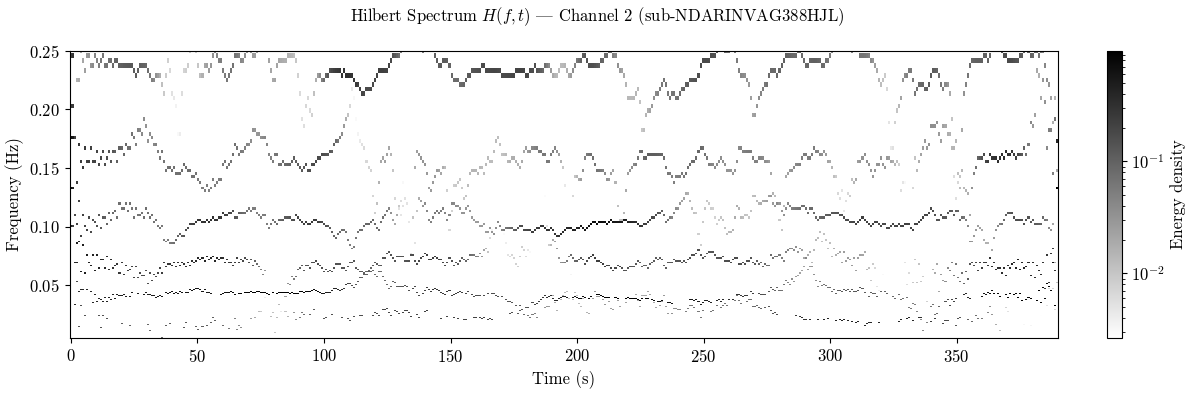

In [35]:
# ---------------------------------------------------------------------------
# Plot: 2D Hilbert spectrum H(omega, t) per channel
# ---------------------------------------------------------------------------
cmap = "gray_r"

for ch in channels_to_plot:
    H = hilbert_spectrum[ch]  # shape [n_freq, n_timepoints]

    pos = H[H > 0]
    if pos.size > 0:
        vmin = np.percentile(pos, 1)
        vmax = np.percentile(pos, 99)
        norm = mcolors.LogNorm(vmin=vmin, vmax=vmax)
    else:
        vmin, vmax = H.min(), H.max()
        norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    fig, ax = plt.subplots(
      figsize=(12, 4)
      )
    fig.suptitle(f"Hilbert Spectrum $H(f, t)$ | Channel {ch} ({SUBJECT_ID})")

    mesh = ax.pcolormesh(time_axis, freq_axis, H, shading="auto", cmap=cmap, norm=norm)
    ax.set_ylabel("Frequency (Hz)")
    # ax.set_yscale("log")
    ax.set_ylim(0.005, 0.25)
    ax.set_xlabel("Time (s)")
    fig.colorbar(mesh, ax=ax, label="Energy density")

plt.show()

In [33]:
# ---------------------------------------------------------------------------
# Diagnose hilbert_spectrum values
# ---------------------------------------------------------------------------
for ch in channels_to_plot:
    H = hilbert_spectrum[ch]
    pos = H[H > 0]
    print(f"Channel {ch}: min={H.min():.4e}, max={H.max():.4e}, "
          f"n_positive={pos.size}/{H.size}, "
          f"n_nan={np.isnan(H).sum()}, n_inf={np.isinf(H).sum()}")

Channel 2: min=0.0000e+00, max=1.2878e+00, n_positive=2854/109312, n_nan=0, n_inf=0


/var/folders/_w/yxnxx2rn2t11qwh4kx9h9g680000gn/T/ipykernel_37878/111130302.py:26: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=[0, 0, 1, 0.98])


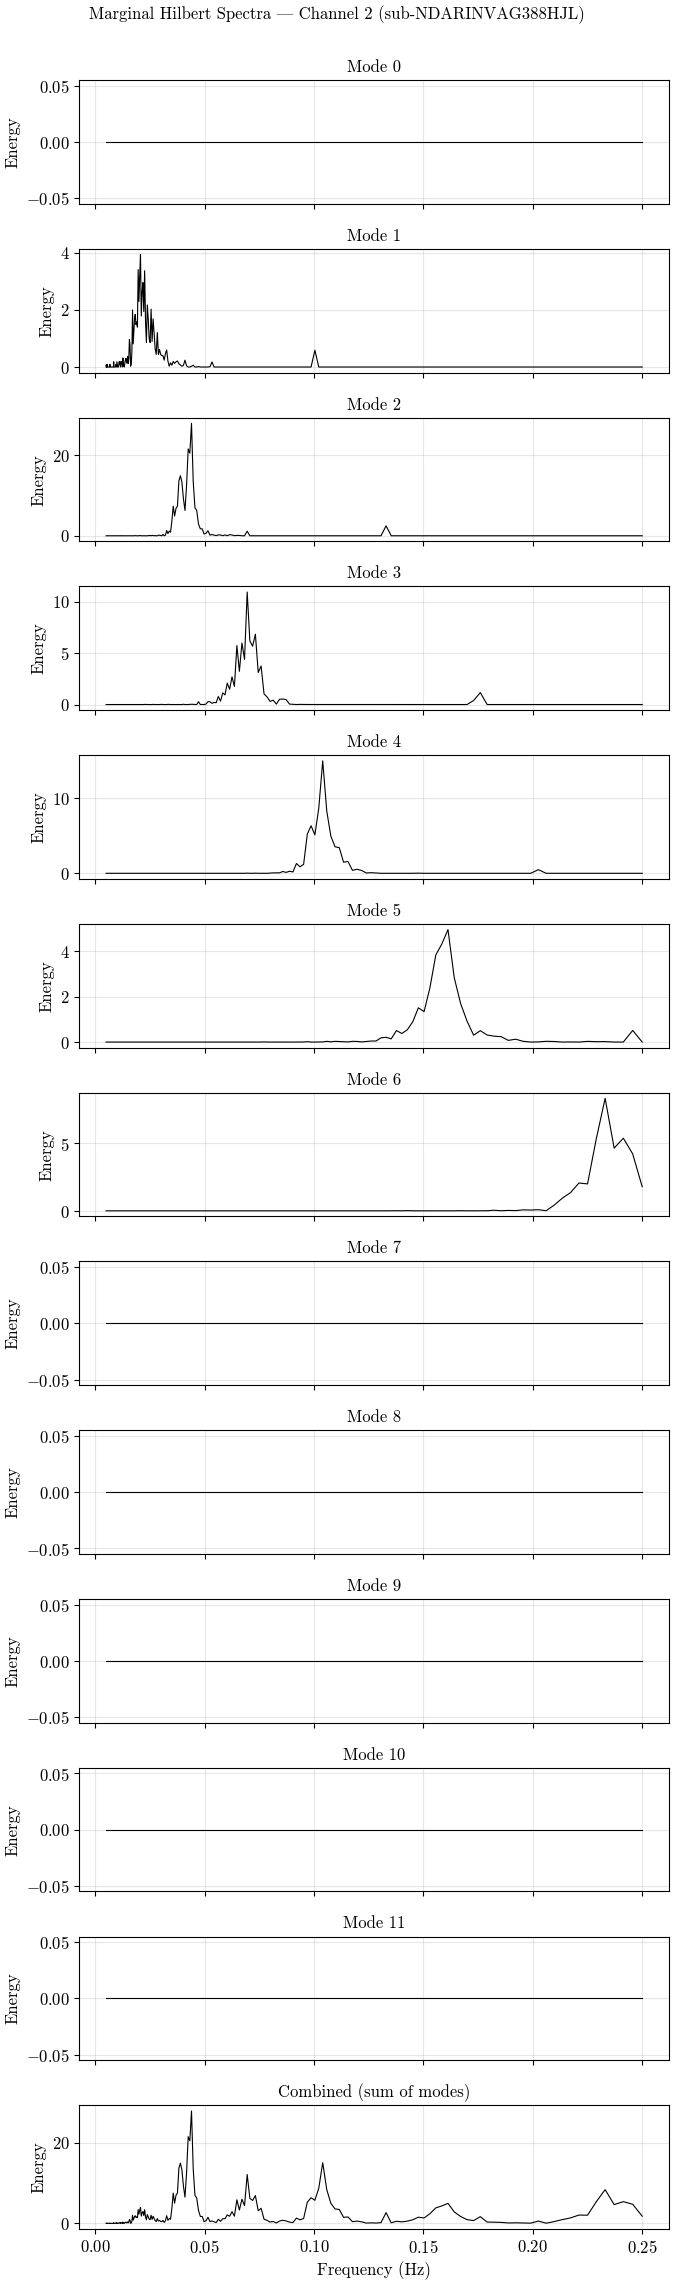

In [34]:
# ---------------------------------------------------------------------------
# Plot: per-mode marginal spectra + combined, one figure per channel
# ---------------------------------------------------------------------------
for ch in channels_to_plot:
    fig, axes = plt.subplots(
        n_modes + 1, 1,
        figsize=(7.0, 1.8 * (n_modes + 1)),
        sharex=True,
    )

    fig.suptitle(f"Marginal Hilbert Spectra | Channel {ch} ({SUBJECT_ID})")

    for k in range(n_modes):
        axes[k].plot(freq_axis, marginal_spectra[k, ch, :], color="k", linewidth=0.8)
        axes[k].set_ylabel("Energy")
        axes[k].set_title(f"Mode {k}")
        axes[k].grid(True, alpha=0.3)

    combined = marginal_spectra[:, ch, :].sum(axis=0)
    axes[-1].plot(freq_axis, combined, color="k", linewidth=0.8)
    axes[-1].set_ylabel("Energy")
    axes[-1].set_xlabel("Frequency (Hz)")
    axes[-1].set_title("Combined (sum of modes)")
    axes[-1].grid(True, alpha=0.3)

    fig.tight_layout(rect=[0, 0, 1, 0.98])

plt.show()